In [1]:
import pandas as pd
import h5py
import json
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pickle

In [2]:
experiment_path = (
    "/Users/clairenastaskin/data/2025-03-14/run-01-wrist-fingers/"
)
probe_event_stream = os.path.join(experiment_path, "streams/probe_events_sub.pkl")
task_event_stream = os.path.join(experiment_path, "streams/task_events_sub.pkl")
power_doppler_frame_course_path = os.path.join(
    experiment_path, "timecourse_zscore_9-3_coord_116_44_32.txt"
)

with open(probe_event_stream, "rb") as f:
    probe_events = pickle.load(f)


with open(task_event_stream, "rb") as f:
    task_event = pickle.load(f)
print(task_event)

power_doppler_frame_course = pd.read_csv(
    power_doppler_frame_course_path, sep="\t", header=None
)

               trial_type       onset   duration
0   right_fingers_tapping   35.554466  16.069546
1       left_wrist_motion   69.568000  17.002027
2   right_fingers_tapping  101.082765  14.191462
3      right_wrist_motion  133.672050  12.291012
4       left_wrist_motion  160.897160  12.161839
5      right_wrist_motion  185.556319  12.381396
6       left_wrist_motion  214.728619  14.585533
7       left_wrist_motion  241.482650  11.094837
8   right_fingers_tapping  266.762926  12.364374
9      right_wrist_motion  294.558169  14.127560
10     right_wrist_motion  325.659304  16.668656
11  right_fingers_tapping  370.030702  13.477051
12  right_fingers_tapping  396.116108  15.101246
13      left_wrist_motion  423.222869  12.548063
14  right_fingers_tapping  448.507755  15.016434
15     right_wrist_motion  480.216131  14.196999
16      left_wrist_motion  510.671812  17.966647
17     right_wrist_motion  541.146377  12.910999
18     right_wrist_motion  567.763412  17.412493
19  right_fingers_ta

In [3]:
print(probe_events.shape)

(338, 4)


In [4]:
power_doppler_time_course = pd.DataFrame(
    {
        "timestamp": probe_events["time_stamp"].values,
        "power_doppler_value": power_doppler_frame_course.iloc[:, 0].values,
    }
)

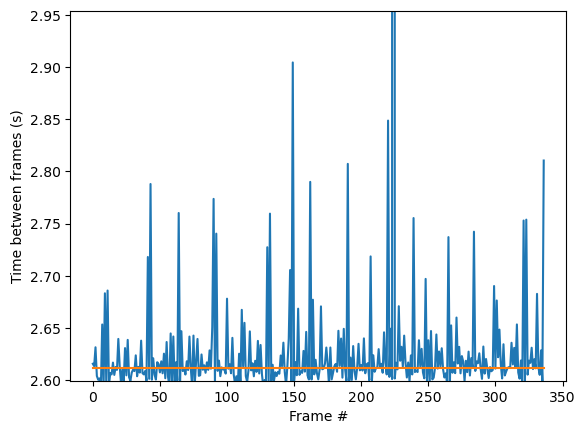

In [23]:
diff_time_course = np.diff(power_doppler_time_course.timestamp)
mediane = np.median(diff_time_course)
twentyfithpercentile = np.percentile(diff_time_course,25)
seventythpercentile = np.percentile(diff_time_course,75)
perc_10, perc_90 = np.percentile(diff_time_course, (10, 90))

fig, ax = plt.subplots()
ax.plot(diff_time_course)
ax.set_xlabel("Frame #", fontsize=10)
ax.set_ylabel("Time between frames (s)", fontsize=10)
ax.set_ylim(perc_10 , perc_90+0.3)
ax.plot(mediane*np.ones_like(diff_time_course))

In [6]:
print(task_event)

               trial_type       onset   duration
0   right_fingers_tapping   35.554466  16.069546
1       left_wrist_motion   69.568000  17.002027
2   right_fingers_tapping  101.082765  14.191462
3      right_wrist_motion  133.672050  12.291012
4       left_wrist_motion  160.897160  12.161839
5      right_wrist_motion  185.556319  12.381396
6       left_wrist_motion  214.728619  14.585533
7       left_wrist_motion  241.482650  11.094837
8   right_fingers_tapping  266.762926  12.364374
9      right_wrist_motion  294.558169  14.127560
10     right_wrist_motion  325.659304  16.668656
11  right_fingers_tapping  370.030702  13.477051
12  right_fingers_tapping  396.116108  15.101246
13      left_wrist_motion  423.222869  12.548063
14  right_fingers_tapping  448.507755  15.016434
15     right_wrist_motion  480.216131  14.196999
16      left_wrist_motion  510.671812  17.966647
17     right_wrist_motion  541.146377  12.910999
18     right_wrist_motion  567.763412  17.412493
19  right_fingers_ta

In [7]:
task_list_type = task_event.trial_type.unique()
print(task_list_type)

['right_fingers_tapping' 'left_wrist_motion' 'right_wrist_motion']


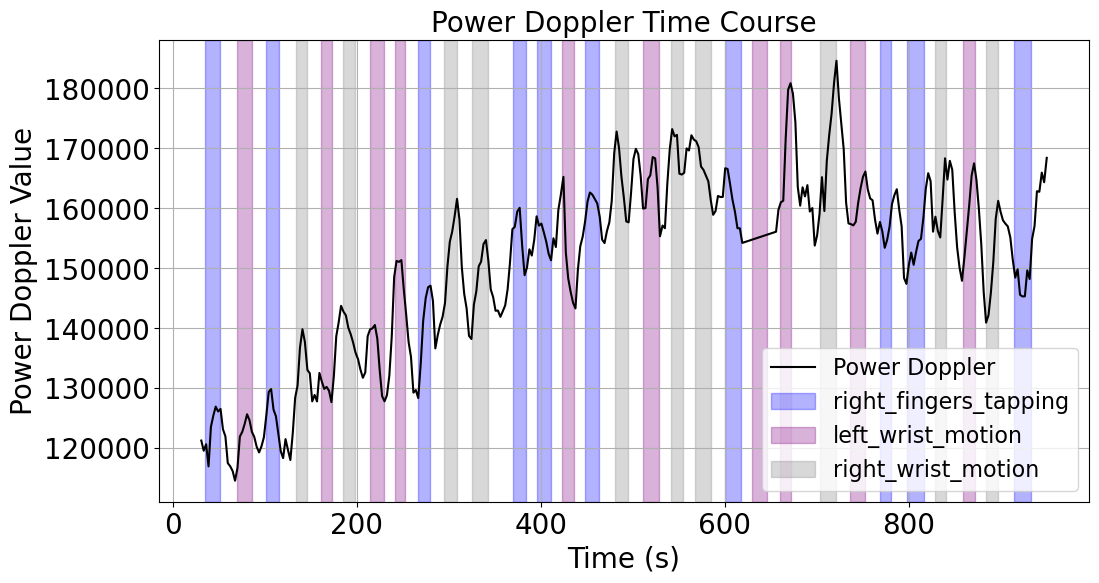

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(
    power_doppler_time_course.timestamp,
    power_doppler_time_course.power_doppler_value,
    color="black",
    label="Power Doppler"
)

task_colors = ['blue','purple', 'gray', 'lightgreen']

# Add colored rectangles for stimulus periods
for task_index in range(len(task_list_type)):
    task = task_list_type[task_index]
    task_events_timing = pd.DataFrame()
    task_events_timing["Event"] = ["start", "stop"] * len(
        task_event[task_event["trial_type"] == task]
    )
    task_events_timing["Timestamp"] = [
        onset
        for onset, duration in zip(
            task_event[task_event["trial_type"] == task]["onset"],
            task_event[task_event["trial_type"] == task]["duration"],
        )
        for _ in range(2)
    ]
    task_events_timing.loc[task_events_timing["Event"] == "stop", "Timestamp"] += (
        task_event[task_event["trial_type"] == task]["duration"].values.repeat(1)
    )
    task_events_timing = task_events_timing.sort_values("Timestamp").reset_index(drop=True)
    start_times = task_events_timing[task_events_timing["Event"] == "start"]["Timestamp"]
    stop_times = task_events_timing[task_events_timing["Event"] == "stop"]["Timestamp"]
    for start, stop in zip(start_times, stop_times):
        plt.axvspan(start, stop, color=task_colors[task_index], alpha=0.3, label=task if start == start_times.iloc[0] else "")

plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Power Doppler Value", fontsize=20)
plt.title("Power Doppler Time Course", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.legend(fontsize=16)
plt.show()

In [9]:
import scipy.io as sio

# Load the eigenvectors spatial data
eigen_vectors_spatial = sio.loadmat(
    "/Users/clairenastaskin/data/2025-02-10/Forest001_ses-20250210_task-wrist+fingers_run-01/eigen_vectors_spatial.mat"
)

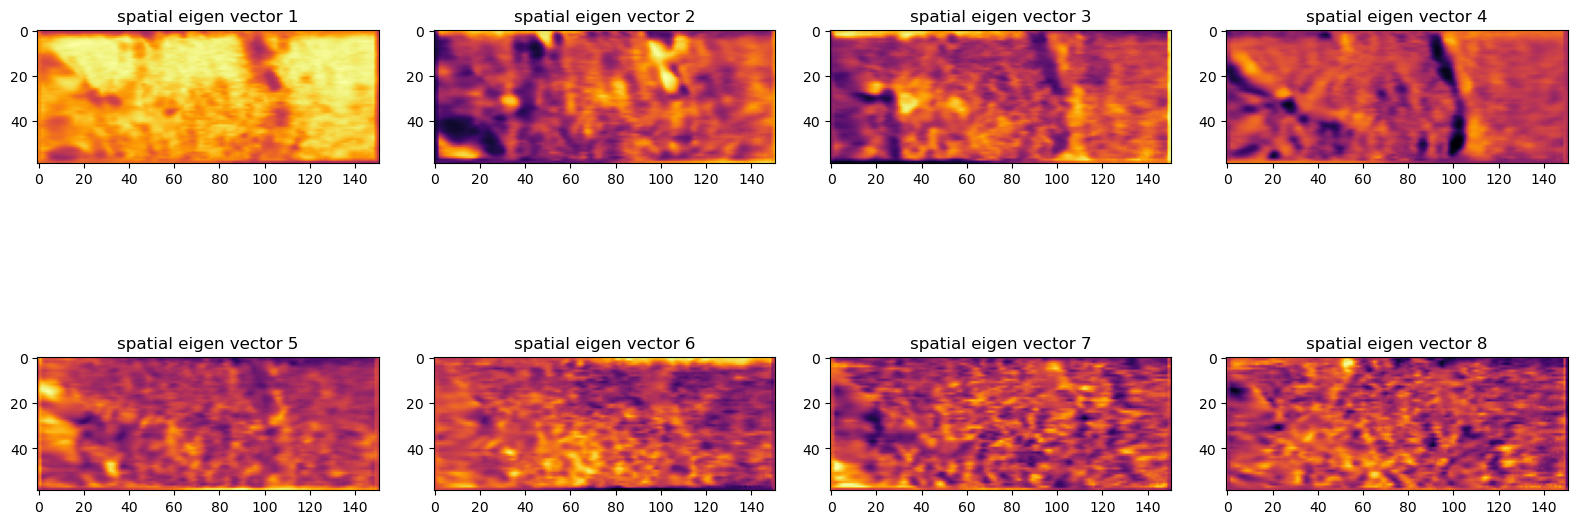

In [10]:
# Create a figure with 8 subplots arranged in 2 rows and 4 columns
plt.figure(figsize=(16, 8))

# Get the data array and reshape if needed
eigen_data = eigen_vectors_spatial["eigen_vectors_spatial"]
tmp = eigen_data.flatten()

# Plot each eigenvector
for i in range(8):
    plt.subplot(2, 4, i + 1)
    eig_2_plot = np.squeeze(eigen_data[:, 35, :, i])
    plt.imshow(np.rot90(eig_2_plot, k=3), cmap="inferno")
    plt.clim(-np.max(np.abs(eig_2_plot)), np.max(np.abs(eig_2_plot)))
    plt.title(f"spatial eigen vector {i + 1}")

plt.tight_layout()
plt.show()